# Handwritten Digit Classification using CNN and RNN

## Importing Libraries

In [3]:
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import transforms
import torch.optim as optim
from torch.utils.data import DataLoader

## Data Loading and Preprocessing

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])


In [10]:
train_set = MNIST(root= "./data", train=True, download=True, transform=transform)
test_set = MNIST(root= "./data", train=False, download=True, transform=transform)

In [11]:
train_loader = DataLoader( train_set, batch_size=64, shuffle=True)
test_loader = DataLoader( test_set, batch_size=64)

In [12]:
X_train, y_train = next(iter(train_loader))
print(X_train.shape)
print(y_train.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


## CNN Model

In [20]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.conv_layers = nn.Sequential(
            #1st layer
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            #2nd layer
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            #3rd layer
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.fc_layers= nn.Sequential(
            nn.Linear(3*3*128, 256),
            nn.ReLU(),

            nn.Linear(256,10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = self.fc_layers(x)
        return x
            
        

In [21]:
model = CNN()

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## Training CNN

In [23]:
epochs = 10
train_losses = []
val_losses = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for xb,yb in train_loader:
        optimizer.zero_grad()
        outputs = model.forward(xb)
        loss= criterion(outputs,yb)
        loss.backward()
        optimizer.step()
        train_loss+=loss.item()
    epoch_train_loss= train_loss/len(train_loader)
    train_losses.append(epoch_train_loss)
    val_loss = 0.0
    model.eval()
    with torch.no_grad():
        for xb,yb in test_loader:
            outputs = model.forward(xb)
            loss = criterion(outputs,yb)
            val_loss+=loss.item()
        epoch_val_loss = val_loss/len(test_loader)
        val_losses.append(epoch_val_loss)
    print(f"Epoch {epoch+1}/{epochs} : training loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

Epoch 1/10 : training loss = 0.14945300567353062 & val loss = 0.046380795628980995
Epoch 2/10 : training loss = 0.04335405032314521 & val loss = 0.03183268077068504
Epoch 3/10 : training loss = 0.03003239863611602 & val loss = 0.029210798793092702
Epoch 4/10 : training loss = 0.02340642642808459 & val loss = 0.026679593577317723
Epoch 5/10 : training loss = 0.017498443447998797 & val loss = 0.024187748378533068
Epoch 6/10 : training loss = 0.014666098562102638 & val loss = 0.025570867202387274
Epoch 7/10 : training loss = 0.012570883387482438 & val loss = 0.025976174790425438
Epoch 8/10 : training loss = 0.011877429805361758 & val loss = 0.033623931525437314
Epoch 9/10 : training loss = 0.00931236819301128 & val loss = 0.037645369126751975
Epoch 10/10 : training loss = 0.00739567216430884 & val loss = 0.034198335483282084


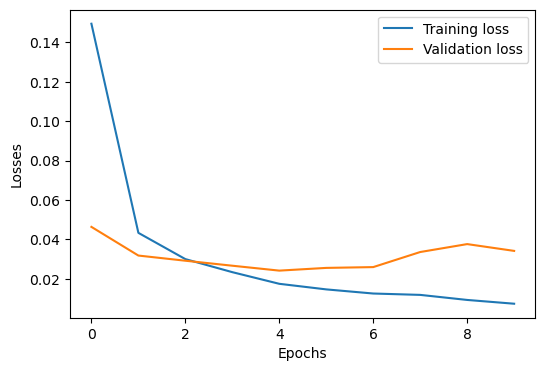

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
loss_df = pd.DataFrame({
    "Training Loss" : train_losses,
    "Val Loss": val_losses
})
plt.figure(figsize=(6, 4))
plt.plot(loss_df["Training Loss"], label="Training loss")
plt.plot(loss_df["Val Loss"], label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()


## CNN Evalutaion

In [32]:
correct = 0
total = 0
test_loss = 0
all_predictions = []
all_labels = []
model.eval()

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)

        loss = criterion(outputs, yb)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += yb.size(0)
        correct += (predicted == yb).sum().item()
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

accuracy = 100 * correct / total
test_loss = test_loss / len(test_loader)

print("Test Loss:", test_loss)
print("Test Accuracy:", accuracy, "%")

Test Loss: 0.034198335483282084
Test Accuracy: 99.13 %


In [33]:
cm = confusion_matrix(all_labels, all_predictions)
print(cm)

[[ 976    1    2    0    0    0    0    1    0    0]
 [   0 1132    0    1    0    0    0    2    0    0]
 [   0    0 1029    0    0    0    0    3    0    0]
 [   0    0    2 1005    0    1    0    2    0    0]
 [   0    1    1    0  971    0    2    0    2    5]
 [   1    1    0    7    0  882    0    0    0    1]
 [   4    3    1    0    0    3  946    0    1    0]
 [   0    1    8    0    0    0    0 1018    0    1]
 [   1    1    4    0    0    2    0    2  960    4]
 [   0    0    0    0    3    7    0    5    0  994]]


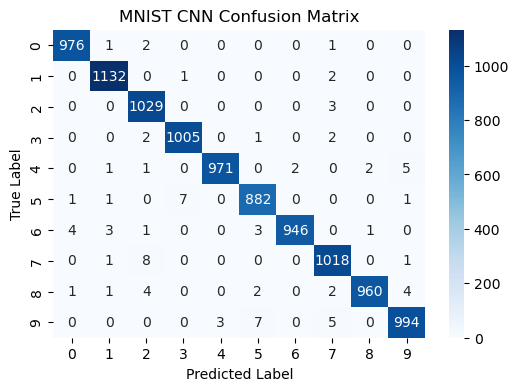

In [34]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST CNN Confusion Matrix")
plt.show()

* Accurancy of CNN model is 99.13%  

## RNN Model

In [47]:
class RNN(nn.Module):
    def __init__(self,input_size, hidden_size=128, num_layers=1):
        super().__init__()
        self.hidden_size=hidden_size
        self.num_layers=num_layers

        self.rnn  = nn.RNN(input_size, hidden_size,num_layers, batch_first=True)

        self.fc = nn.Linear(128,10)
    def forward(self,x):
        out,hidden = self.rnn(x)
        out = self.fc(out[:,-1,:])
        return out

In [48]:
input_size=28
model = RNN(input_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## Training RNN

In [49]:
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for xb,yb in train_loader:
        optimizer.zero_grad()
        xb = xb.squeeze(1)
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    epoch_train_loss = running_loss/ len(train_loader)

    print(f"Epoch {epoch+1}/{epochs}: Loss = {epoch_train_loss}")
    

Epoch 1/10: Loss = 0.732170886258835
Epoch 2/10: Loss = 0.3315867677505718
Epoch 3/10: Loss = 0.250907925888896
Epoch 4/10: Loss = 0.22534705147639647
Epoch 5/10: Loss = 0.1920631522280988
Epoch 6/10: Loss = 0.17842467748788374
Epoch 7/10: Loss = 0.16330417183372797
Epoch 8/10: Loss = 0.1497771746711309
Epoch 9/10: Loss = 0.15212188923417697
Epoch 10/10: Loss = 0.14102663206004068


In [52]:
correct = 0
total = 0
test_loss = 0
all_predictions = []
all_labels = []
model.eval()

with torch.no_grad():
    for xb, yb in test_loader:
        xb=xb.squeeze(1)
        outputs = model(xb)

        loss = criterion(outputs, yb)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += yb.size(0)
        correct += (predicted == yb).sum().item()
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

accuracy = 100 * correct / total
test_loss = test_loss / len(test_loader)

print("Test Loss:", test_loss)
print("Test Accuracy:", accuracy, "%")
cm = confusion_matrix(all_labels, all_predictions)
print(cm)

Test Loss: 0.13677911502220164
Test Accuracy: 96.16 %
[[ 934    0    1    1    0    3   39    1    1    0]
 [   0 1120    4    1    0    5    2    0    2    1]
 [   2    2  998    3    1    3    6    8    9    0]
 [   0    0    8  974    0   15    0    4    3    6]
 [   0    1    2    1  940    3   15    2    2   16]
 [   5    2    0    9    4  829    7    1    8   27]
 [   3    4    0    0    3    1  940    0    7    0]
 [   1    6    9    1    2    4    0  990    1   14]
 [   0    5    8    0    5    4    6    5  937    4]
 [   2    3    1    2   23   11    1    4    8  954]]


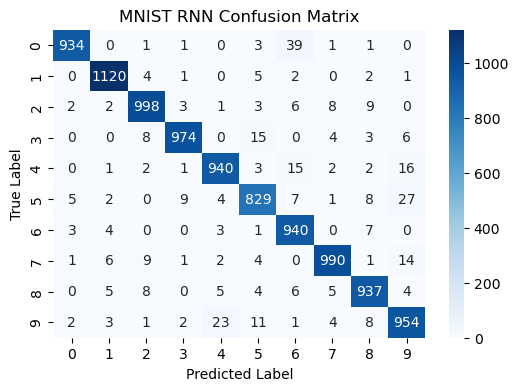

In [53]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST RNN Confusion Matrix")
plt.show()

* Accuracy of RNN model is 96.16%

## Conclusion

* #### The CNN achieved a test accuracy of 99.13%, while the RNN achieved 96.16%. The CNN produced 87 misclassifications compared with 384 for the RNN. The CNN confusion matrix shows that its predictions are concentrated more strongly along the main diagonal, whereas the RNN has larger off-diagonal errors, particularly for the pairs 0→6, 5→9, and 9→4.